In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

from src.utils.team_info import *
from src.utils.helper_functions import *
from src.pipeline.props_pipeline.ppm_pipeline import *
from src.pipeline.props_pipeline.min_pipeline import *
from src.features.feature_engineer.ppm_features import ppm_features

warnings.filterwarnings("ignore")

In [2]:
pd.set_option('display.max_columns', None)

s23 = pd.read_csv('data/raw/season_stats/S23.csv').sort_values(by='GAME_DATE')
s24 = pd.read_csv('data/raw/season_stats/S24.csv').sort_values(by='GAME_DATE')
s25 = pd.read_csv('data/raw/season_stats/S25.csv').sort_values(by='GAME_DATE')
s26 = pd.read_csv('data/raw/season_stats/S26.csv').sort_values(by='GAME_DATE')
s26.tail()

,Unnamed: 0,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,START_POSITION,pos,age,STARTING
26440,3,2025-26,1631248,Baylor Scheierman,Baylor,1610612738,BOS,Boston Celtics,22501186,2026-04-12,BOS vs. ORL,W,38.806667,8,20,0.400,6,14,0.429,8,8,1.000,0,7,7,7,3,2,1,0,3,7,30,15,54.9,0,0,56.0,1,38:48,1,110.1,111.6,111.6,91.0,96.4,96.4,19.1,15.2,15.2,0.280,2.33,20.6,0.000,0.140,0.079,8.8,8.9,0.550,0.638,0.281,0.279,108.95,105.14,87.61,105.14,0.197,86,8.0,20.0,36,87,0.414,19,50,0.380,22,22,1.000,8,38,46,24,17.0,10,6,5,23,19,113,5.0,106.9,107.6,98.9,102.9,8.0,4.8,0.667,1.41,17.3,0.216,0.650,0.450,0.162,0.523,0.584,107.4,105.0,87.50,105,0.550,1610612753,ORL,Orlando Magic,36,91,0.396,12,43,0.279,24,30,0.800,14,36,50,22,19.0,6,5,6,19,23,108,-5.0,98.9,102.9,106.9,107.6,-8.0,-4.8,0.611,1.16,14.9,0.350,0.784,0.550,0.181,0.462,0.518,107.4,105.0,87.50,105,0.450,F,SG,25.0,1
26439,2,2025-26,1642382,Branden Carlson,Branden,1610612760,OKC,Oklahoma City Thunder,22501196,2026-04-12,OKC vs. PHX,L,42.233333,10,20,0.500,5,10,0.500,1,2,0.500,1,9,10,1,1,2,5,4,0,2,26,-18,59.5,1,0,56.0,1,42:14,1,111.3,112.5,112.5,131.2,134.5,134.5,-19.9,-22.0,-22.0,0.034,1.00,4.3,0.021,0.220,0.114,4.3,4.4,0.625,0.623,0.222,0.228,101.24,99.45,82.87,99.45,0.124,88,10.0,20.0,41,95,0.432,18,46,0.391,3,9,0.333,9,27,36,32,10.0,9,7,8,8,9,103,-32.0,103.0,105.1,130.3,137.8,-27.2,-32.7,0.780,3.20,22.4,0.228,0.587,0.388,0.102,0.526,0.520,101.8,98.0,81.67,98,0.403,1610612756,PHX,Phoenix Suns,56,101,0.554,20,41,0.488,3,6,0.500,13,41,54,28,13.0,5,8,7,9,8,135,32.0,130.3,137.8,103.0,105.1,27.2,32.7,0.500,2.15,19.3,0.413,0.772,0.612,0.133,0.653,0.651,101.8,98.0,81.67,98,0.597,C,C,26.0,1
26438,1,2025-26,1642847,Jeremiah Fears,Jeremiah,1610612740,NOP,New Orleans Pelicans,22501195,2026-04-12,NOP @ MIN,L,41.383333,12,28,0.429,0,5,0.000,12,14,0.857,3,7,10,5,2,2,1,3,3,8,36,0,62.5,1,0,57.0,1,41:23,1,116.9,119.8,119.8,122.3,118.6,118.6,-5.4,1.2,1.2,0.172,2.50,12.2,0.052,0.152,0.096,4.9,4.9,0.429,0.527,0.305,0.308,111.60,111.93,93.27,111.93,0.147,96,12.0,28.0,45,107,0.421,5,21,0.238,31,38,0.816,20,32,52,20,9.0,9,6,13,28,27,126,-6.0,111.8,117.8,123.5,122.2,-11.7,-4.5,0.444,2.22,13.1,0.394,0.692,0.525,0.084,0.444,0.509,109.8,107.5,89.58,107,0.432,1610612750,MIN,Minnesota Timberwolves,45,89,0.506,10,37,0.270,32,43,0.744,12,35,47,32,11.0,5,13,6,27,28,132,6.0,123.5,122.2,111.8,117.8,11.7,4.5,0.711,2.91,20.6,0.308,0.606,0.475,0.102,0.562,0.612,109.8,107.5,89.58,108,0.568,G,PG,19.0,1
26445,7,2025-26,16

In [13]:
res = []
for df in [s23, s24, s25, s26]:
    df["GAME_DATE"] = pd.to_datetime(df["GAME_DATE"])
    df = df.sort_values(["PLAYER_ID", "GAME_DATE"]).reset_index(drop=True)
    df = ppm_features(df)

    df['TEAM_PTS_PER_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_PTS_PER_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['PTS_PER_MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_MIN_RANK_L5'] = (df.groupby(['TEAM_ID','GAME_DATE'])['MIN_roll5'].rank(ascending=False, method='dense'))
    df['TEAM_USG_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['USG_PCT_roll10'].rank(ascending=False, method='dense'))
    df['TEAM_TS_RANK_L10'] = (df.groupby(['TEAM_ID','GAME_DATE'])['TS_PCT_roll10'].rank(ascending=False, method='dense'))
    # df['TRUE_USG_L10'] = df['POSS_roll10'] / df['TEAM_POSS_AVG']
    df['MIN_TREND'] = df['MIN_5_ewm'] - df['3PM_PER_MIN_10_ewm']
    df['USG_TREND'] = df['USG_PCT_5_ewm'] - df['USG_PCT_10_ewm']
    df['PPM_TREND'] = df['PTS_PER_MIN_5_ewm'] - df['PTS_PER_MIN_10_ewm']

    df['PPM_L10_X_MIN_L10'] = df['PTS_PER_MIN_10_ewm'] * df['MIN_10_ewm']
    df['TS_PCT_X_USG_PCT'] = df['TS_PCT_season_avg'] * df['USG_PCT_season_avg']
    # df['PTS_PER_MIN_X_OPP_DEF_RATING'] = df['PTS_PER_MIN_10_ewm'] * df['OPP_DEF_RATING_AVG']
    # df['PTS_PER_MIN_X_OPP_POSS'] = df['PTS_PER_MIN_10_ewm'] * df['OPP_POSS_AVG']
    # df['PTS_PER_MIN_X_OPP_PACE'] = df['PTS_PER_MIN_10_ewm'] * df['OPP_PACE_AVG']
    df['FGM_PER_MIN_X_OPP_FG%_ALLOWED'] = df['FGM_PER_MIN_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']
    df['FGM_PER_MIN_X_OPP_DEF_RATING'] = df['FGM_PER_MIN_10_ewm'] * df['OPP_DEF_RATING']
    df['FGA_PER_MIN_X_OPP_FG%_ALLOWED'] = df['FGA_PER_MIN_10_ewm'] * df['OPP_TEAM_FG%_ALLOWED']
    df['FGA_PER_MIN_X_OPP_DEF_RATING'] = df['FGA_PER_MIN_10_ewm'] * df['OPP_DEF_RATING']
    
    df['3PA_PER_MIN_X_OPP_FG3%_ALLOWED'] = df['3PA_PER_MIN_10_ewm'] * df['OPP_TEAM_FG3%_ALLOWED']
    df['3PM_PER_MIN_X_OPP_FG3%_ALLOWED'] = df['3PM_PER_MIN_10_ewm'] * df['OPP_TEAM_FG3%_ALLOWED']
    df['FTA_PER_MIN_X_OPP_FTA_ALLOWED'] = df['FTA_PER_MIN_10_ewm'] * df['OPP_TEAM_FTA_ALLOWED']
    df['PTS_PER_MIN_X_OPP_PTS_ALLOWED'] = df['PTS_PER_MIN_10_ewm'] * df['OPP_TEAM_PTS_ALLOWED']
    df['POSS_PER_MIN_X_OPP_POSS_ALLOWED'] = df['POSS_PER_MIN_10_ewm'] * df['OPP_TEAM_POSS_ALLOWED']

    # --- EFG / TS / Shooting Quality ---
    df['FGM_PER_MIN_X_OPP_EFG_ALLOWED']     = df['FGM_PER_MIN_10_ewm']     * df['OPP_TEAM_EFG_PCT_ALLOWED']
    df['FGA_PER_MIN_X_OPP_EFG_ALLOWED']     = df['FGA_PER_MIN_10_ewm']     * df['OPP_TEAM_EFG_PCT_ALLOWED']
    df['PTS_PER_MIN_X_OPP_TS_ALLOWED']      = df['PTS_PER_MIN_10_ewm']     * df['OPP_TEAM_TS_PCT_ALLOWED']
    df['TS_PCT_X_OPP_TS_ALLOWED']           = df['TS_PCT_season_avg']       * df['OPP_TEAM_TS_PCT_ALLOWED']

    # --- DEF RATING (composite defensive quality) ---
    # df['FGM_PER_MIN_X_OPP_DEF_RATING']      = df['FGM_PER_MIN_10_ewm']     * df['OPP_DEF_RATING_AVG']
    # df['FGA_PER_MIN_X_OPP_DEF_RATING']      = df['FGA_PER_MIN_10_ewm']     * df['OPP_DEF_RATING_AVG']
    # df['3PM_PER_MIN_X_OPP_DEF_RATING']      = df['3PM_PER_MIN_10_ewm']     * df['OPP_DEF_RATING_AVG']
    # df['FTA_PER_MIN_X_OPP_DEF_RATING']      = df['FTA_PER_MIN_10_ewm']     * df['OPP_DEF_RATING_AVG']

    # --- Foul Drawing (PFD) ---
    df['FTA_PER_MIN_X_OPP_PFD_ALLOWED']     = df['FTA_PER_MIN_10_ewm']     * df['OPP_TEAM_PFD_ALLOWED']
    df['PTS_PER_MIN_X_OPP_PFD_ALLOWED']     = df['PTS_PER_MIN_10_ewm']     * df['OPP_TEAM_PFD_ALLOWED']

    # --- Turnover Rate (fewer turnovers = more scoring opps) ---
    df['PTS_PER_MIN_X_OPP_TOV_ALLOWED']     = df['PTS_PER_MIN_10_ewm']     * df['OPP_TEAM_TM_TOV_PCT_ALLOWED']
    df['POSS_PER_MIN_X_OPP_TOV_ALLOWED']    = df['POSS_PER_MIN_10_ewm']    * df['OPP_TEAM_TM_TOV_PCT_ALLOWED']

    # --- Rebounding (DREB_PCT — limits second chance pts) ---
    df['PTS_PER_MIN_X_OPP_DREB_ALLOWED']    = df['PTS_PER_MIN_10_ewm']     * df['OPP_TEAM_DREB_PCT_ALLOWED']
    df['POSS_PER_MIN_X_OPP_DREB_ALLOWED']   = df['POSS_PER_MIN_10_ewm']    * df['OPP_TEAM_DREB_PCT_ALLOWED']

    player_stats = df.groupby('PLAYER_ID')['PTS_PER_MIN']
    df['PPM_SEASON_STD'] = player_stats.transform(lambda x: x.expanding().std().shift(1))
    df['PPM_SEASON_MEAN'] = player_stats.transform(lambda x: x.expanding().mean().shift(1))
    std_dev = df['PPM_SEASON_STD']
    df['PPM_ROLE_Z_SCORE'] = np.where(
    std_dev > 0, 
    (df['PTS_PER_MIN_10_ewm'] - df['PPM_SEASON_MEAN']) / std_dev, 0)
    df["GP"] = df.groupby("PLAYER_ID").cumcount()

    le = LabelEncoder()
    df['PLAYER_ENCODED'] = le.fit_transform(df['PLAYER_ID'])
    df['POSITION_ENCODED'] = le.fit_transform(df['pos'])
    df['OPP_ENCODED'] = le.fit_transform(df['OPP_TEAM_ID'])
    df['TEAM_ENCODED'] = le.fit_transform(df['TEAM_ID'])

    df = df[df['MIN'] >= 15]           # remove garbage time / DNP-adjacent games
    df = df[df['GP'] >= 8]            # cold start protection
    df = df[df['MIN_10_ewm'] >= 18]   # only real rotation players
    res.append(df)

df = pd.concat(res, ignore_index=True)
df.drop(columns=['Unnamed: 0'], inplace=True)
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
print(df['MIN_10_ewm'].min()) 
df.sample(5)

The dataset has 57576 rows and 460 columns.
18.0


,SEASON_YEAR,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,AVAILABLE_FLAG,MIN_SEC,TEAM_COUNT,E_OFF_RATING,OFF_RATING,sp_work_OFF_RATING,E_DEF_RATING,DEF_RATING,sp_work_DEF_RATING,E_NET_RATING,NET_RATING,sp_work_NET_RATING,AST_PCT,AST_TO,AST_RATIO,OREB_PCT,DREB_PCT,REB_PCT,TM_TOV_PCT,E_TOV_PCT,EFG_PCT,TS_PCT,USG_PCT,E_USG_PCT,E_PACE,PACE,PACE_PER40,sp_work_PACE,PIE,POSS,FGM_PG,FGA_PG,TEAM_FGM,TEAM_FGA,TEAM_FG_PCT,TEAM_FG3M,TEAM_FG3A,TEAM_FG3_PCT,TEAM_FTM,TEAM_FTA,TEAM_FT_PCT,TEAM_OREB,TEAM_DREB,TEAM_REB,TEAM_AST,TEAM_TOV,TEAM_STL,TEAM_BLK,TEAM_BLKA,TEAM_PF,TEAM_PFD,TEAM_PTS,TEAM_PLUS_MINUS,TEAM_E_OFF_RATING,TEAM_OFF_RATING,TEAM_E_DEF_RATING,TEAM_DEF_RATING,TEAM_E_NET_RATING,TEAM_NET_RATING,TEAM_AST_PCT,TEAM_AST_TO,TEAM_AST_RATIO,TEAM_OREB_PCT,TEAM_DREB_PCT,TEAM_REB_PCT,TEAM_TM_TOV_PCT,TEAM_EFG_PCT,TEAM_TS_PCT,TEAM_E_PACE,TEAM_PACE,TEAM_PACE_PER40,TEAM_POSS,TEAM_PIE,OPP_TEAM_ID,OPP_OPP_ABBREVIATION_base,OPP_OPP_NAME_base,OPP_FGM,OPP_FGA,OPP_FG_PCT,OPP_FG3M,OPP_FG3A,OPP_FG3_PCT,OPP_FTM,OPP_FTA,OPP_FT_PCT,OPP_OREB,OPP_DREB,OPP_REB,OPP_AST,OPP_TOV,OPP_STL,OPP_BLK,OPP_BLKA,OPP_PF,OPP_PFD,OPP_PTS,OPP_PLUS_MINUS,OPP_E_OFF_RATING,OPP_OFF_RATING,OPP_E_DEF_RATING,OPP_DEF_RATING,OPP_E_NET_RATING,OPP_NET_RATING,OPP_AST_PCT,OPP_AST_TO,OPP_AST_RATIO,OPP_OREB_PCT,OPP_DREB_PCT,OPP_REB_PCT,OPP_TM_TOV_PCT,OPP_EFG_PCT,OPP_TS_PCT,OPP_E_PACE,OPP_PACE,OPP_PACE_PER40,OPP_POSS,OPP_PIE,pos,age,STARTING,PTS_PER_MIN,POSS_PER_MIN,FGA_PER_MIN,FGM_PER_MIN,3PA_PER_MIN,3PM_PER_MIN,FTA_PER_MIN,FTM_PER_MIN,MIN_roll3,PTS_roll3,USG_PCT_roll3,PLUS_MINUS_roll3,POSS_roll3,PTS_PER_MIN_roll3,TS_PCT_roll3,AST_TO_roll3,FGA_PER_MIN_roll3,3PA_PER_MIN_roll3,FTA_PER_MIN_roll3,AST_roll3,TOV_roll3,MIN_roll5,PTS_roll5,USG_PCT_roll5,PLUS_MINUS_roll5,POSS_roll5,PTS_PER_MIN_roll5,TS_PCT_roll5,AST_TO_roll5,FGA_PER_MIN_roll5,3PA_PER_MIN_roll5,FTA_PER_MIN_roll5,AST_roll5,TOV_roll5,MIN_roll10,PTS_roll10,USG_PCT_roll10,PLUS_MINUS_roll10,POSS_roll10,PTS_PER_MIN_roll10,TS_PCT_roll10,AST_TO_roll10,FGA_PER_MIN_roll10,3PA_PER_MIN_roll10,FTA_PER_MIN_roll10,AST_roll10,TOV_roll10,MIN_3_ewm,PTS_3_ewm,USG_PCT_3_ewm,PLUS_MINUS_3_ewm,POSS_3_ewm,PTS_PER_MIN_3_ewm,POSS_PER_MIN_3_ewm,TS_PCT_3_ewm,AST_TO_3_ewm,FGA_PER_MIN_3_ewm,3PA_PER_MIN_3_ewm,FTA_PER_MIN_3_ewm,AST_3_ewm,TOV_3_ewm,REB_3_ewm,FGM_PER_MIN_3_ewm,3PM_PER_MIN_3_ewm,FTM_PER_MIN_3_ewm,MIN_5_ewm,PTS_5_ewm,USG_PCT_5_ewm,PLUS_MINUS_5_ewm,POSS_5_ewm,PTS_PER_MIN_5_ewm,POSS_PER_MIN_5_ewm,TS_PCT_5_ewm,AST_TO_5_ewm,FGA_PER_MIN_5_ewm,3PA_PER_MIN_5_ewm,FTA_PER_MIN_5_ewm,AST_5_ewm,TOV_5_ewm,REB_5_ewm,FGM_PER_MIN_5_ewm,3PM_PER_MIN_5_ewm,FTM_PER_MIN_5_ewm,MIN_10_ewm,PTS_10_ewm,USG_PCT_10_ewm,PLUS_MINUS_10_ewm,POSS_10_ewm,PTS_PER_MIN_10_ewm,POSS_PER_MIN_10_ewm,TS_PCT_10_ewm,AST_TO_10_ewm,FGA_PER_MIN_10_ewm,3PA_PER_MIN_10_ewm,FTA_PER_MIN_10_ewm,AST_10_ewm,TOV_10_ewm,REB_10_ewm,FGM_PER_MIN_10_ewm,3PM_PER_MIN_10_ewm,FTM_PER_MIN_10_ewm,MIN_lag1,PTS_lag1,PLUS_MINUS_lag1,PIE_lag1,STARTING_lag1,POSS_lag1,USG_PCT_lag1,PTS_PER_MIN_lag1,POSS_PER_MIN_lag1,MIN_lag2,PTS_lag2,PLUS_MINUS_lag2,PIE_lag2,STARTING_lag2,POSS_lag2,USG_PCT_lag2,PTS_PER_MIN_lag2,POSS_PER_MIN_lag2,STARTER_ROLL10_PCT,MIN_season_avg,PTS_season_avg,USG_PCT_season_avg,POSS_season_avg,PF_season_avg,OFF_RATING_season_avg,DEF_RATING_season_avg,PTS_PER_MIN_season_avg,FGA_PER_MIN_season_avg,FTA_PER_MIN_season_avg,3PA_PER_MIN_season_avg,TS_PCT_season_avg,TOP_USG_PLAYER_VALUE,TOP_USG_PLAYER_ACTIVE,TOP_USG_PLAYER_STARTING,LINEUP_USG_SHIFT,TEAM_PACE_roll10,TEAM_PTS_roll10,TEAM_POSS_roll10,TEAM_TS_PCT_roll10,MIN_share_proxy,PTS_share_proxy,TEAM_FG%_ALLOWED,TEAM_FG3%_ALLOWED,TEAM_FG3A_ALLOWED,TEAM_FG3M_ALLOWED,TEAM_FTA_ALLOWED,TEAM_PTS_ALLOWED,TEAM_POSS_ALLOWED,TEAM_PFD_ALLOWED,TEAM_DEF_RATING_ALLOWED,TEAM_EFG_PCT_ALLOWED,TEAM_TS_PCT_ALLOWED,TEAM_DREB_PCT_ALLOWED,TEAM_TM_TOV_PCT_ALLOWED,OPP_TEAM_FG%_ALLOWED,OPP_

In [ ]:
# df.to_csv('data/processed/training/S26_TRAINING_PPM.csv', index=False)

In [14]:
PPM_FEATURES = [
  # Context
  "PLAYER_ENCODED",
  "POSITION_ENCODED",

  # Player Stats
  "TEAM_MIN_RANK_L10",
  "TEAM_USG_RANK_L10",
  "PPM_SEASON_STD",
  "PTS_PER_MIN_season_avg",
  "PPM_ROLE_Z_SCORE",
  'MIN_TREND',
  'USG_TREND',
  
  # Player × Opponent interactions
  "TS_PCT_X_USG_PCT",
  "PTS_PER_MIN_X_OPP_PTS_ALLOWED",
  "FGA_PER_MIN_X_OPP_FG%_ALLOWED",
  "FGM_PER_MIN_X_OPP_FG%_ALLOWED",
  "FTA_PER_MIN_X_OPP_PFD_ALLOWED",
  "3PA_PER_MIN_X_OPP_FG3%_ALLOWED",
  "3PM_PER_MIN_X_OPP_FG3%_ALLOWED",

  # Opponent Stats
  "PACE_DIFFERENTIAL"
]

In [15]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

# ── 1. Base dataframe ─────────────────────────────────────────────────────────
ppm_df = (
    df[PPM_FEATURES + ["PTS_PER_MIN", "GAME_DATE"]]
    .sort_values("GAME_DATE")
    .reset_index(drop=True)
)

X = ppm_df[PPM_FEATURES]
y = ppm_df["PTS_PER_MIN"]

quantiles = [0.10, 0.50, 0.90]
#Best params: {'n_estimators': 1918, 'max_depth': 3, 'learning_rate': 0.06506556523722509, 
# 'subsample': 0.5168657885224003, 'colsample_bytree': 0.7200985113112991, 'reg_alpha': 0.035292086310568814, 
# 'reg_lambda': 4.755281357016035, 'min_child_weight': 7}
XGB_PARAMS = dict(
    objective          = "reg:quantileerror",
    n_estimators       = 1918,
    max_depth          = 3,
    learning_rate      = 0.06506556523722509,
    subsample          = 0.5168657885224003,
    colsample_bytree   = 0.7200985113112991,
    reg_alpha          = 0.035292086310568814,
    reg_lambda         = 4.755281357016035,
    min_child_weight   = 7,
    n_jobs             = -1,
    random_state       = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key        = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds


def score_fold(actual, preds, models, fold_label):
    lower    = preds["q_0.10"]
    median   = preds["q_0.50"]
    upper    = preds["q_0.90"]
    coverage = np.mean((actual >= lower) & (actual <= upper))
    metrics  = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mean_absolute_error(actual, median),
        "r2":             r2_score(actual, median),
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }
    print(f"{fold_label:30s} | MAE: {metrics['mae']:.3f} | "
          f"R²: {metrics['r2']:.3f} | "
          f"80% Coverage: {coverage:.1%}")
    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparameter tuning)
#
# Use this to compare models or features without data leakage.
# NOT your final performance estimate — train set grows each fold
# which inflates later folds.
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────")
print(f"Data shape: {X.shape}")
tscv        = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, f"TSCV fold {fold+1}")
    tscv_results.append(metrics)

maes = [r["mae"] for r in tscv_results]
r2s  = [r["r2"]  for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


── Phase 1: TimeSeriesSplit ─────────────────────────────────────
Data shape: (57576, 17)
TSCV fold 1                    | MAE: 0.157 | R²: 0.335 | 80% Coverage: 78.8%
TSCV fold 2                    | MAE: 0.155 | R²: 0.322 | 80% Coverage: 79.6%
TSCV fold 3                    | MAE: 0.157 | R²: 0.323 | 80% Coverage: 79.5%
TSCV fold 4                    | MAE: 0.158 | R²: 0.303 | 80% Coverage: 79.0%
TSCV fold 5                    | MAE: 0.161 | R²: 0.292 | 80% Coverage: 79.1%

TimeSeriesSplit Summary
  MAE      : 0.158 ± 0.002
  R²       : 0.315  ± 0.015
  Coverage : 79.2% ± 0.3%  (target ~80%)


In [15]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# # Uses X, y, TimeSeriesSplit from your Phase 1 cell
# tscv = TimeSeriesSplit(n_splits=3)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=40, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

In [16]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (final validation / production simulation)
#
# Fixed training window that slides forward — mimics how you'll
# actually retrain in production. Use these numbers to decide
# whether to trust the model with real money.
# ════════════════════════════════════════════════════════════════════════════

TRAIN_WINDOW = int(len(ppm_df) * 0.50)   # fixed window size (games)
STEP_SIZE    = int(len(ppm_df) * 0.10)   # retrain every N games
N_FOLDS      = 4

wf_results = []

for fold in range(N_FOLDS):
    train_start = fold * STEP_SIZE
    train_end   = train_start + TRAIN_WINDOW
    val_end     = train_end   + STEP_SIZE

    if val_end > len(ppm_df):
        break

    X_tr  = X.iloc[train_start:train_end]
    X_val = X.iloc[train_end:val_end]
    y_tr  = y.iloc[train_start:train_end]
    y_val = y.iloc[train_end:val_end]

    date_start = ppm_df["GAME_DATE"].iloc[train_start]
    date_end   = ppm_df["GAME_DATE"].iloc[train_end - 1]
    date_val   = ppm_df["GAME_DATE"].iloc[val_end - 1]

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    label   = f"WF fold {fold+1} ({date_end} → {date_val})"
    metrics = score_fold(y_val.values, preds, models, label)
    metrics.update({"train_start": date_start, "train_end": date_end, "val_end": date_val})
    wf_results.append(metrics)

maes = [r["mae"] for r in wf_results]
r2s  = [r["r2"]  for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]
print(f"\nWalk-Forward Summary")
print(f"  MAE      : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Drift check — is the model degrading over time?
print("\nMAE over folds (should be stable, not rising):")
for r in wf_results:
    bar = "█" * int(r["mae"] * 4)
    print(f"  {r['fold']:30s} {r['mae']:.3f}  {bar}")   

WF fold 1 (2024-11-10 00:00:00 → 2025-01-16 00:00:00) | MAE: 0.158 | R²: 0.324 | 80% Coverage: 79.3%
WF fold 2 (2025-01-16 00:00:00 → 2025-03-19 00:00:00) | MAE: 0.155 | R²: 0.311 | 80% Coverage: 79.8%
WF fold 3 (2025-03-19 00:00:00 → 2025-12-15 00:00:00) | MAE: 0.159 | R²: 0.300 | 80% Coverage: 78.4%
WF fold 4 (2025-12-15 00:00:00 → 2026-02-11 00:00:00) | MAE: 0.157 | R²: 0.326 | 80% Coverage: 79.7%

Walk-Forward Summary
  MAE      : 0.157 ± 0.001
  R²       : 0.315  ± 0.010
  Coverage : 79.3% ± 0.5%  (target ~80%)

MAE over folds (should be stable, not rising):
  WF fold 1 (2024-11-10 00:00:00 → 2025-01-16 00:00:00) 0.158  
  WF fold 2 (2025-01-16 00:00:00 → 2025-03-19 00:00:00) 0.155  
  WF fold 3 (2025-03-19 00:00:00 → 2025-12-15 00:00:00) 0.159  
  WF fold 4 (2025-12-15 00:00:00 → 2026-02-11 00:00:00) 0.157  


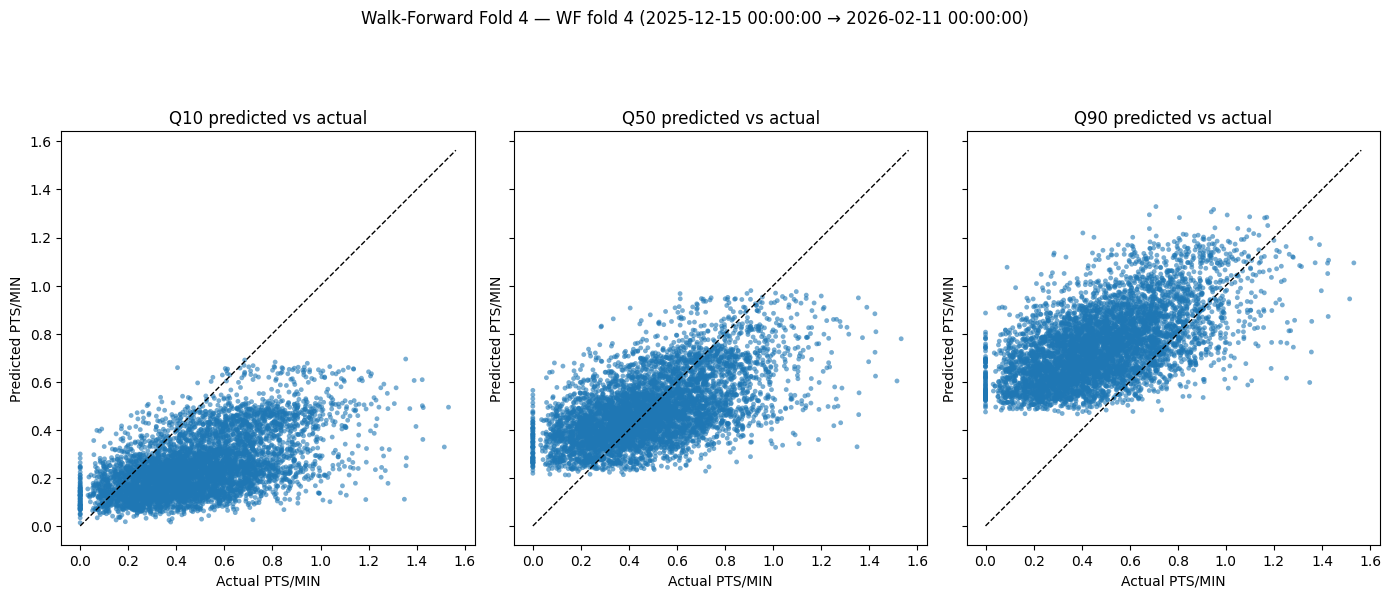

Coverage per quantile (should match quantile value):
  Q10: 10.8%  (target 10%, delta +0.8%)
  Q50: 50.7%  (target 50%, delta +0.7%)
  Q90: 90.4%  (target 90%, delta +0.4%)

80% interval width (Q10→Q90):
  mean : 0.51 min
  median: 0.50 min
  std  : 0.05 min


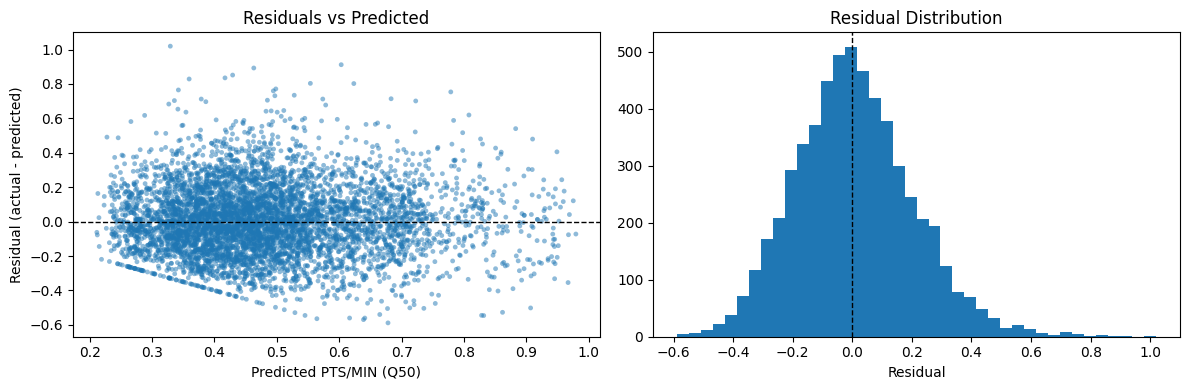


Residual summary:
  mean bias : +0.007 min  (close to 0 = unbiased)
  std       : 0.200 min


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# ── pull from last walk-forward fold ─────────────────────────────────────────
last_fold   = wf_results[-1]
last_fold_n = last_fold["n"]

# re-identify the val slice from the last WF fold
fold        = N_FOLDS - 1
train_start = fold * STEP_SIZE
train_end   = train_start + TRAIN_WINDOW
val_end     = train_end + STEP_SIZE

X_val_last  = X.iloc[train_end:val_end]
y_val_last  = y.iloc[train_end:val_end]

# re-run predictions from the stored models (retrain if you didn't store them)
# if you stored models per fold, swap this block out
models_last, preds_last = fit_quantile_models(
    X.iloc[train_start:train_end],
    y.iloc[train_start:train_end],
    X_val_last,
    y_val_last,
)

y_true   = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name} predicted vs actual")
    ax.set_xlabel("Actual PTS/MIN")
    ax.set_ylabel("Predicted PTS/MIN")
    ax.set_aspect("equal", adjustable="box")

plt.suptitle(f"Walk-Forward Fold {N_FOLDS} — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

# ── coverage per quantile ─────────────────────────────────────────────────────
print("Coverage per quantile (should match quantile value):")
for name, y_pred in preds.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})")

# ── interval width distribution ───────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean : {interval_width.mean():.2f} min")
print(f"  median: {np.median(interval_width):.2f} min")
print(f"  std  : {interval_width.std():.2f} min")

# ── residual plot (median only) ───────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted PTS/MIN (Q50)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.3f} min  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.3f} min")

In [18]:
ppm_df = df[PPM_FEATURES + ["MIN", "GAME_DATE", "PLAYER_NAME"]].sort_values("GAME_DATE").reset_index(drop=True)

val_df = ppm_df.iloc[train_end:val_end].reset_index(drop=True)

player_col = "PLAYER_NAME" if "PLAYER_NAME" in val_df.columns else None
if player_col is None:
    raise ValueError("Add PLAYER_NAME to ppm_df columns (see comment above).")

pred50 = np.asarray(pred_mid).reshape(-1)
pred90 = np.asarray(pred_high).reshape(-1)
out = pd.DataFrame({
    "player": val_df[player_col].values,
    "actual_ppm": np.asarray(y_true).reshape(-1),
    "pred_ppm_q50": pred50,
    "pred_ppm_q90": pred90,
})
out["error"] = out["actual_ppm"] - out["pred_ppm_q50"]
out["abs_error"] = out["error"].abs()

# optional: tie-break sort
if "GAME_DATE" in val_df.columns:
    out["game_date"] = val_df["GAME_DATE"].values

print(out.sort_values("abs_error", ascending=True).head(20).to_string(index=False))
print(f"\nMAE (Q50): {out['abs_error'].mean():.3f} | RMSE: {np.sqrt((out['error']**2).mean()):.3f}")

          player  actual_ppm  pred_ppm_q50  pred_ppm_q90     error  abs_error  game_date
    Jaxson Hayes    0.362173      0.362208      0.637734 -0.000035   0.000035 2026-01-22
 Duncan Robinson    0.450939      0.450983      0.702977 -0.000043   0.000043 2026-02-06
   Miles Bridges    0.527704      0.527750      0.782992 -0.000045   0.000045 2026-01-26
   Naji Marshall    0.567823      0.567920      0.838256 -0.000096   0.000096 2026-01-24
Payton Pritchard    0.508475      0.508604      0.833058 -0.000130   0.000130 2025-12-30
        Jay Huff    0.442674      0.442499      0.725975  0.000174   0.000174 2026-01-19
    Kobe Sanders    0.297193      0.297000      0.528911  0.000194   0.000194 2026-01-25
Donte DiVincenzo    0.385852      0.385563      0.633415  0.000289   0.000289 2026-02-09
 Jaden McDaniels    0.427818      0.427507      0.662240  0.000311   0.000311 2026-01-16
  Draymond Green    0.354610      0.354980      0.603945 -0.000370   0.000370 2025-12-31
Brandon Williams    0


── q_0.10 ──


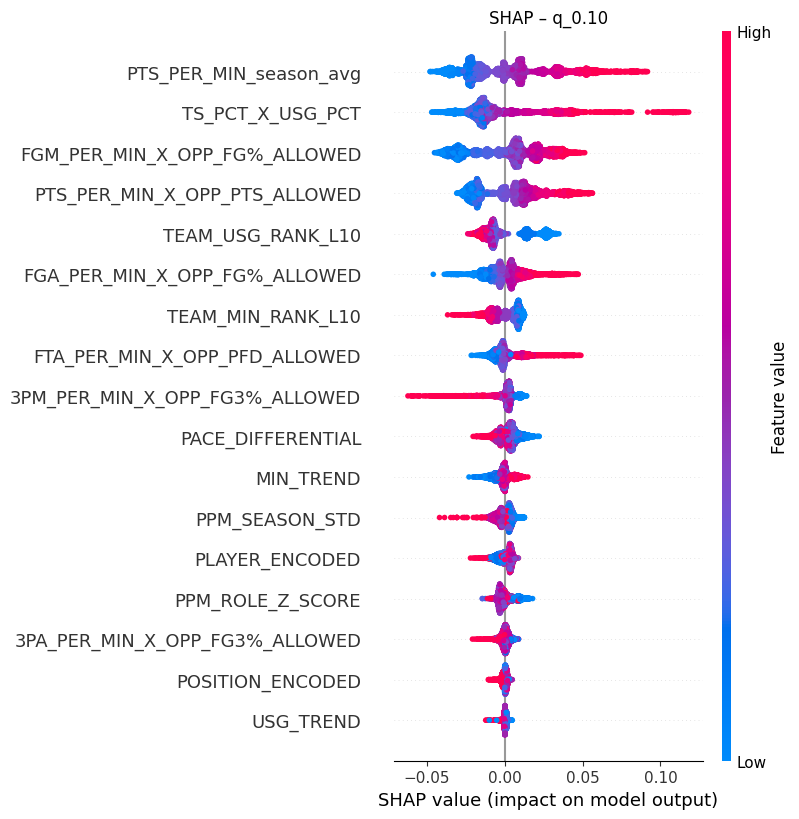


── q_0.50 ──


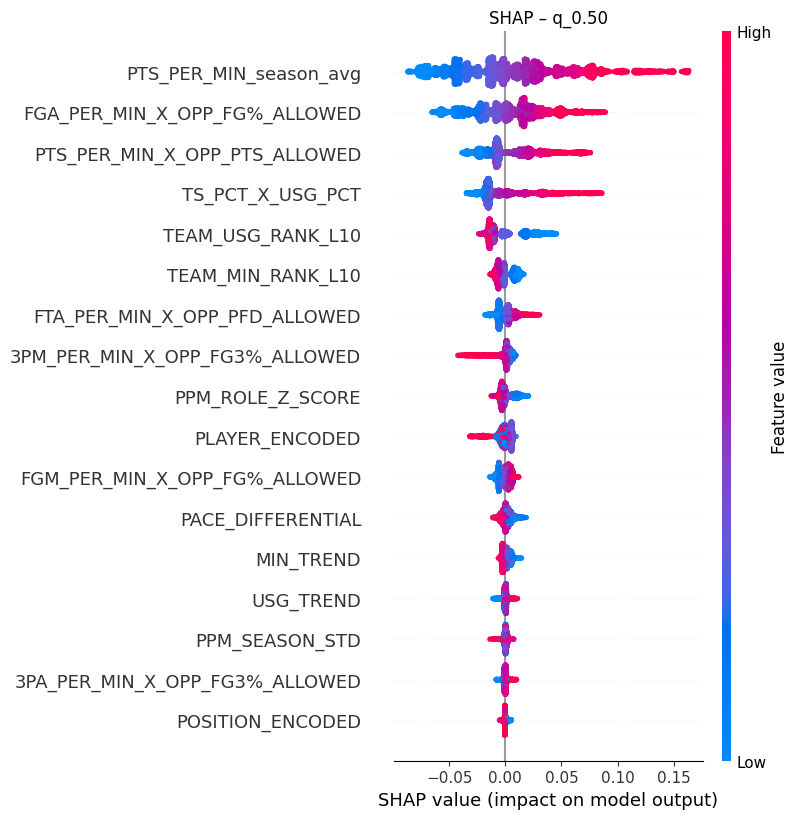


── q_0.90 ──


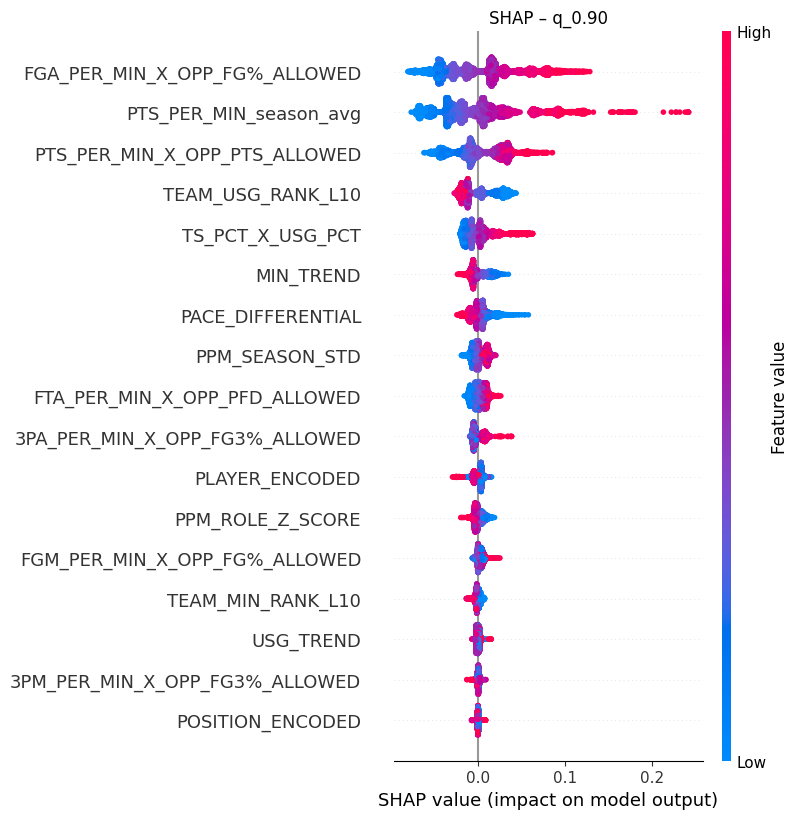

In [19]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP – {q_key}")
    plt.tight_layout()
    plt.show()

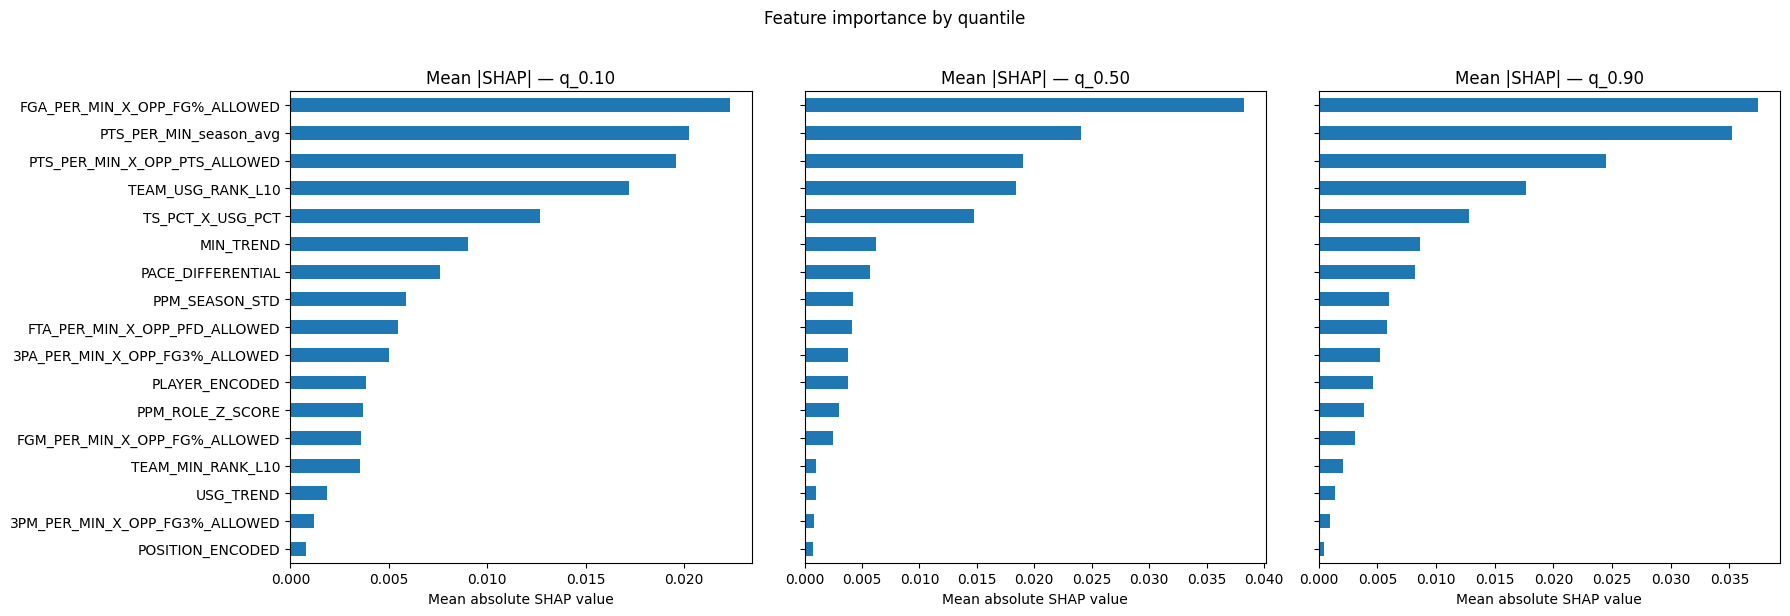

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, (q_key, model) in zip(axes, models_last.items()):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer(X_val_last)

    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
    feat_imp      = pd.Series(mean_abs_shap, index=PPM_FEATURES).sort_values(ascending=True)

    feat_imp.plot(kind="barh", ax=ax)
    ax.set_title(f"Mean |SHAP| — {q_key}")
    ax.set_xlabel("Mean absolute SHAP value")

plt.suptitle("Feature importance by quantile", y=1.02)
plt.tight_layout()
plt.show()

In [21]:
explainer_low  = shap.TreeExplainer(models_last["q_0.10"])
explainer_high = shap.TreeExplainer(models_last["q_0.90"])

shap_low  = explainer_low(X_val_last).values
shap_high = explainer_high(X_val_last).values

divergence = pd.Series(
    np.abs(shap_high - shap_low).mean(axis=0),
    index=PPM_FEATURES
).sort_values(ascending=False)

print("\nFeatures driving Q10 vs Q90 spread (uncertainty drivers):")
print(divergence.head(10).to_string())


Features driving Q10 vs Q90 spread (uncertainty drivers):
FGA_PER_MIN_X_OPP_FG%_ALLOWED     0.028491
FGM_PER_MIN_X_OPP_FG%_ALLOWED     0.018724
PTS_PER_MIN_season_avg            0.014194
MIN_TREND                         0.011709
PTS_PER_MIN_X_OPP_PTS_ALLOWED     0.011341
TS_PCT_X_USG_PCT                  0.009415
PPM_SEASON_STD                    0.009102
TEAM_USG_RANK_L10                 0.006856
3PA_PER_MIN_X_OPP_FG3%_ALLOWED    0.006300
TEAM_MIN_RANK_L10                 0.005942


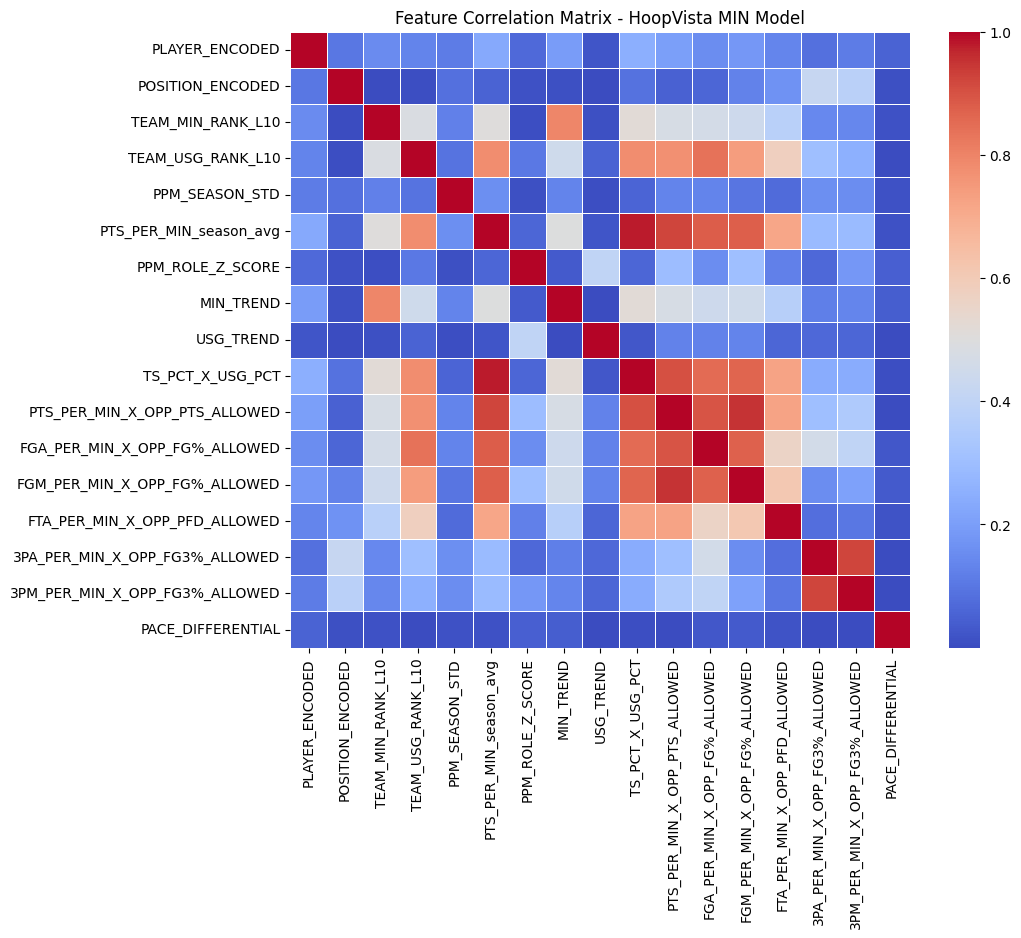

--- High Correlation Report (Threshold > 0.95) ---
TS_PCT_X_USG_PCT <-> PTS_PER_MIN_season_avg: 0.9797
FGM_PER_MIN_X_OPP_FG%_ALLOWED <-> PTS_PER_MIN_X_OPP_PTS_ALLOWED: 0.9513


['TS_PCT_X_USG_PCT', 'FGM_PER_MIN_X_OPP_FG%_ALLOWED']

In [22]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the MIN model.
    """
    # Calculate correlation matrix
    corr_matrix = df[features].corr().abs()
    
    # Create a mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features with correlation above threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Plotting the Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista MIN Model')
    plt.show()
    
    # Detailed report of high correlations
    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))
            
    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")
            
    return to_drop

# Usage with your specific list
correlated_features = analyze_correlations(df, PPM_FEATURES)
correlated_features

In [23]:
import joblib
from pathlib import Path

# save_dir = Path("models")
# save_dir.mkdir(exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_last,       # from final WF fold
    "feature_names":   PPM_FEATURES,
    "fold_metrics":    wf_results,        # full validation history
    "train_end":       last_fold["train_end"],
    "val_end":         last_fold["val_end"],
}

save_path = f"ppm_quantile_xgb_{last_fold['val_end'].date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle         = joblib.load(save_path)
models_loaded  = bundle["quantile_models"]
feature_names  = bundle["feature_names"]

# sanity check — should match your walk-forward MAE
test_preds = models_loaded["q_0.50"].predict(X_val_last)
print(f"Loaded model MAE: {mean_absolute_error(y_val_last, test_preds):.3f}")
print(f"Trained on data up to: {bundle['train_end']}")
print(f"Validated on data up to: {bundle['val_end']}")

# ── inference (new data) ──────────────────────────────────────────────────────
def predict_ppm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a dataframe with the same columns as MIN_FEATURES.
    Returns Q10/Q50/Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })

Saved to ppm_quantile_xgb_2026-02-11.joblib
Loaded model MAE: 0.157
Trained on data up to: 2025-12-15 00:00:00
Validated on data up to: 2026-02-11 00:00:00
